# Exercise 2 - Planung von CO₂-Transportnetz (3B)

VU - Energiemodelle und Analysen

Gruppe 10 - Hannah Bennoui, Peter Geyrhofer, Johannes Tanzer, Clemens Stadler

## Aufgabenstellung

Ein einfaches CO₂-Transportnetz soll für das Jahr 2030 geplant werden. Es besteht aus drei Knotenpunkten:

- **Quelle** (z. B. Industrieanlage): jährliche CO₂-Menge ist bekannt  
- **Onshore-Senke**: maximale Aufnahmekapazität bekannt  
- **Offshore-Senke**: maximale Aufnahmekapazität bekannt  

### Ziel

Minimierung der Infrastrukturkosten für den CO₂-Transport (z. B. Leitungsbau, Kompression, Einspeisung)  
→ Entscheidung über die Verteilung der CO₂-Menge von der Quelle zu den beiden Senken unter Beachtung technischer Kapazitätsgrenzen.

### Zusätzliche Nebenbedingung

Die relative Auslastung beider Senken soll am Ende des Planungszeitraums identisch sein, also:

$$
\frac{\text{eingeleitete Menge in Onshore-Senke}}{\text{maximale Onshore-Kapazität}} =
\frac{\text{eingeleitete Menge in Offshore-Senke}}{\text{maximale Offshore-Kapazität}}
$$

Diese Nebenbedingung stellt sicher, dass beide Senken proportional zu ihrer jeweiligen Kapazität gleich stark genutzt werden.

In [1]:
#Skizze der Aufgabenstellung:

#               Quelle
#                  |
#          ----------------
#          |              |
#    Senke on-shore   Senke off-shore

## Implementierung in Gurobi

In [2]:
from pyomo.environ import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Annahmen
T = 6
timesteps = np.arange(T)

startfüllstand1 = 0 # tCO2
startfüllstand2 = 0 # tCO2
minfüllstand1 = 0 # tCO2
minfüllstand2 = 0 # tCO2
maxfüllstand1 = 100000000 # tCO2
maxfüllstand2 = 300000000 # tCO2

q_CO2 = [20000000,30000000,50000000,60000000,90000000,30000000] #tCO2
c1_opex = 50 # €/tCO2
c2_opex = 90 # €/tCO2
max_cap_pipe1 = 20000000 #tCO2/y
max_cap_pipe2 = 100000000 #tCO2/y


In [3]:
# Pyomo Modell aufstellen
model = ConcreteModel()

# Sets definieren
model.time = Set(initialize = timesteps)

# Parameter definieren
model.c1_opex= Param(model.time, initialize = c1_opex) # Opex Senke 1
model.c2_opex= Param(model.time, initialize = c2_opex) # Opex Senke 2

# Variablen definieren
model.x1 = Var(model.time, within= NonNegativeReals) # Menge_Senke 1
model.x2 = Var(model.time, within= NonNegativeReals) # Menge_Senke 2

model.soc1 = Var(model.time, within = NonNegativeReals) # Speicherfüllstand
model.soc2 = Var(model.time, within = NonNegativeReals) # Speicherfüllstand

# Zielfunktion angeben
model.obj = Objective(
        expr=sum(model.x1[t] * model.c1_opex[t]  + model.x1[t] * model.c1_opex[t] for t in model.time),
        sense=minimize)

# Nebenbedingeungen definieren 
# Speicherbilanz 
def soc_con_rule1(model, t):
    if t == 0:  
        return model.soc1[t] == startfüllstand1
    else:  
        return model.soc1[t] == model.soc1[t-1] + model.x1[t]
model.soc_con1 = Constraint(model.time, rule=soc_con_rule1)

def soc_con_rule2(model, t):
    if t == 0:  
        return model.soc2[t] == startfüllstand2
    else:  
        return model.soc2[t] == model.soc2[t-1] + model.x2[t]
model.soc_con2 = Constraint(model.time, rule=soc_con_rule2)

#Speicher 1
# minimaler Speicherfüllstand
def min_soc_rule1(model, t):
    return model.soc1[t] >= minfüllstand1
model.min_soc_con1 = Constraint(model.time, rule=min_soc_rule1)

# maximaler Speicherfüllstand
def max_soc_rule1(model, t):
    return model.soc1[t] <= maxfüllstand1
model.max_soc_con1 = Constraint(model.time, rule=max_soc_rule1)

# Speicherfüllstand zu Beginn
def start_soc_rule1(model):
    return model.soc1[0] == 0
model.start_soc_con1 = Constraint(rule=start_soc_rule1)

#Speicher 2
# minimaler Speicherfüllstand
def min_soc_rule2(model, t):
    return model.soc2[t] >= minfüllstand2
model.min_soc_con2 = Constraint(model.time, rule=min_soc_rule2)

# maximaler Speicherfüllstand
def max_soc_rule2(model, t):
    return model.soc2[t] <= maxfüllstand2
model.max_soc_con2 = Constraint(model.time, rule=max_soc_rule2)

# Speicherfüllstand zu Beginn
def start_soc_rule2(model):
    return model.soc2[0] == 0
model.start_soc_con2 = Constraint(rule=start_soc_rule2)

# CO2-Bilanz
def q_CO2_rule(model,t):
    return (model.x1[t] + model.x2[t]) == q_CO2[t]
model.q_CO2 = Constraint(model.time, rule = q_CO2_rule)

#Relative Speicherfüllstände
def rel_soc_rule(model):
    return model.soc1[5]/maxfüllstand1 == model.soc2[5]/maxfüllstand2
model.rel_soc_rule = Constraint(rule=rel_soc_rule)

#Technische Kapazitätsgrenzen
def pipe1_cap_rule(model,t):
    return model.x1[t] <= max_cap_pipe1
model.pipe1_cap_rule = Constraint(model.time, rule=pipe1_cap_rule)

def pipe2_cap_rule(model,t):
    return model.x2[t] <= max_cap_pipe2
model.pipe2_cap_rule = Constraint(model.time, rule=pipe2_cap_rule)



In [4]:
solver = SolverFactory('gurobi')
results = solver.solve(model, tee=True)


#Print Entscheidungsvariablenergebnis

print("\nOptimale Werte für x1 und x2:")
for t in model.time:
    print(f"t = {t}:  x1 = {model.x1[t].value:.2f},  x2 = {model.x2[t].value:.2f}")

print("\nSpeicherfüllstände:")
for t in model.time:
    print(f"t = {t}:  soc1 = {model.soc1[t].value:.2f},  soc2 = {model.soc2[t].value:.2f}")

# Print objective function Ergebnis
print(f"\nGesamtkosten (Zielfunktion): {value(model.obj):.2f} €")

# DataFrame mit Ergebnis
results_df = pd.DataFrame({
    't': list(model.time),
    'x1': [model.x1[t].value for t in model.time],
    'x2': [model.x2[t].value for t in model.time],
    'soc1': [model.soc1[t].value for t in model.time],
    'soc2': [model.soc2[t].value for t in model.time],
})

print("\nErgebnisse als DataFrame:")
print(results_df)



Read LP format model from file C:\Users\peter\AppData\Local\Temp\tmp3u7x0jjg.pyomo.lp
Reading time = 0.00 seconds
x1: 57 rows, 24 columns, 84 nonzeros
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 57 rows, 24 columns and 84 nonzeros
Model fingerprint: 0x80969826
Coefficient statistics:
  Matrix range     [3e-09, 1e+00]
  Objective range  [1e+02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+07, 3e+08]
Presolve removed 57 rows and 24 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.5000000e+09   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective  6.500000000e+09

Optimale Werte für x1 und x2:
t =

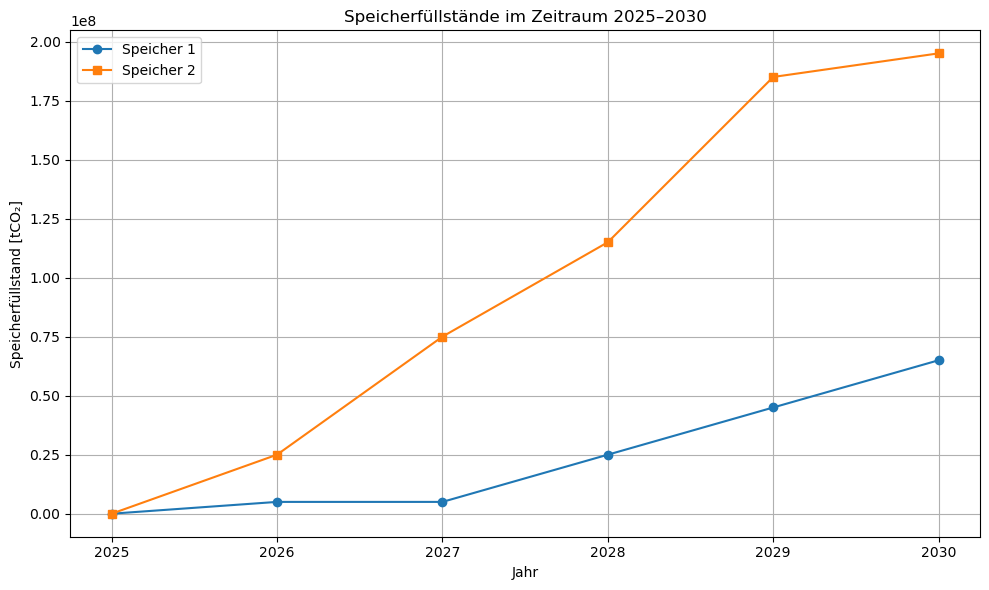

In [5]:
# Plot Speicherstände
years = [2025, 2026, 2027, 2028, 2029, 2030]

plt.figure(figsize=(10, 6))
plt.plot(years, results_df['soc1'], label='Speicher 1', marker='o')
plt.plot(years, results_df['soc2'], label='Speicher 2', marker='s')
plt.xlabel('Jahr')
plt.ylabel('Speicherfüllstand [tCO₂]')
plt.title('Speicherfüllstände im Zeitraum 2025–2030')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation der Ergebnisse

Die Optimierung des CO₂-Transportnetzes hängt maßgeblich von den gewählten Eingangsparametern ab – insbesondere von den Kapazitäten der Senken sowie den Kostenparametern für den Transport. In diesem Fall weist die Offshore-Senke eine deutlich größere maximale Aufnahmekapazität auf als die Onshore-Senke. Entsprechend wurde für sie auch eine höhere maximale Übertragungskapazität angesetzt, was sich unmittelbar auf die Verteilung des CO₂-Transports ausgewirkt hat.

Besonders prägend für das Ergebnis war die zusätzliche Nebenbedingung der gleichmäßigen relativen Auslastung beider Senken. Sie verlangt, dass beide Speicher proportional zu ihrer jeweiligen Maximalkapazität befüllt werden. Im Ergebnis erreichen sowohl die Onshore- als auch die Offshore-Senke eine Auslastung von 65 %, womit die Bedingung vollständig erfüllt ist. Diese Vorgabe verhinderte, dass ausschließlich die wirtschaftlich günstigere oder kapazitätsstärkere Option genutzt wurde – stattdessen musste eine ausgewogene Verteilung erfolgen.

Das optimierte Szenario führt zu Gesamtkosten in Höhe von **6,5 Milliarden Euro** für den CO₂-Transport bis zum Jahr 2030.

Die modellierten Speicherfüllstände am Ende des Planungszeitraums betragen:

- **Onshore-Senke (soc₁):** 65.000.000 Tonnen CO₂  
- **Offshore-Senke (soc₂):** 195.000.000 Tonnen CO₂  

Ein zugehöriger Plot zeigt den zeitlichen Verlauf der Speicherfüllstände beider Senken über den betrachteten Zeitraum. Aus der Visualisierung geht hervor, dass sich beide Speicher synchron füllen und die angestrebte relative Auslastung von 65 % zum Endzeitpunkt erreicht wird. Die Entwicklung der Füllstände folgt dabei dem kostenoptimalen Pfad unter Einhaltung der gegebenen technischen Randbedingungen.

Insgesamt verdeutlichen die Ergebnisse, wie stark sich die Infrastrukturplanung durch zusätzliche restriktive Nebenbedingungen verändert. Ohne die Vorgabe der gleichmäßigen Auslastung wäre eine einseitigere Nutzung mit geringeren Kosten wahrscheinlich gewesen – jedoch auf Kosten einer unausgeglichenen Beanspruchung der verfügbaren Speicherinfrastruktur.
